# Classificação: otimizando modelos de machine learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

## Construindo os modelos iniciais

In [ ]:
dados = pd.read_csv('https://3070-classificacao-otimizacao.s3.us-east-2.amazonaws.com/dados_inadimplencia.csv')
dados

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,16855.246324,2997.000000,12.157324,0,2.0,0.501213,0.003109,0.513171,0.117428,243.0,1
1,13500.000000,2776.050000,12.157324,0,2.0,0.501213,0.269730,0.513171,0.097900,617.0,0
2,11250.000000,2722.188351,12.157324,0,3.0,0.701396,0.518625,0.700184,0.118600,9.0,0
3,27000.000000,6750.000000,3.000000,0,2.0,0.501213,0.649571,0.513171,0.047400,300.0,0
4,22500.000000,3097.800000,12.157324,0,2.0,0.440744,0.509677,0.513171,0.014400,2913.0,1
...,...,...,...,...,...,...,...,...,...,...,...
14573,11250.000000,1893.150000,12.157324,1,2.0,0.501213,0.591424,0.513171,0.117428,545.0,0
14574,33750.000000,4900.050000,17.000000,0,3.0,0.501213,0.563311,0.513171,0.016500,502.0,1
14575,38070.000000,2878.650000,12.157324,0,3.0,0.501213,0.748159,0.513171,0.070100,699.0,0
14576,16855.246324,5154.300000,7.000000,0,2.0,0.501213,0.559936,0.513171,0.030600,1323.0,0


In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14578 entries, 0 to 14577
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      14578 non-null  float64
 1   anuidade_emprestimo  14578 non-null  float64
 2   anos_casa_propria    14578 non-null  float64
 3   telefone_trab        14578 non-null  int64  
 4   avaliacao_cidade     14578 non-null  float64
 5   score_1              14578 non-null  float64
 6   score_2              14578 non-null  float64
 7   score_3              14578 non-null  float64
 8   score_social         14578 non-null  float64
 9   troca_telefone       14578 non-null  float64
 10  inadimplente         14578 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.2 MB


In [ ]:
round(dados['inadimplente'].value_counts(normalize=True)*100, 2)

,proportion
inadimplente,
0,67.65
1,32.35


In [ ]:
x = dados.drop('inadimplente', axis=1)
y = dados['inadimplente']

In [ ]:
RANDOM_STATE = 42

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.33, stratify=y, random_state=RANDOM_STATE)

### Treinando o DecisionTreeClassifier

In [ ]:
modelo_dt = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
modelo_dt.fit(x_treino, y_treino)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
recall_dt = recall_score(y_teste, modelo_dt.predict(x_teste))
print(f'Recall (Decision Tree): {recall_dt:.3f}')

Recall (Decision Tree): 0.143


### Treinando o LogisticRegression

In [ ]:
logistic_pipeline = make_pipeline(StandardScaler(), LogisticRegression(random_state=RANDOM_STATE))
logistic_pipeline.fit(x_treino, y_treino)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(random_state=42))])

In [ ]:
recall_lr = recall_score(y_teste, logistic_pipeline.predict(x_teste))
print(f'Recall (Logistic Regression): {recall_lr:.3f}')

Recall (Logistic Regression): 0.253


## Realizando a busca em grade

### Busca em grade para o DecisionTreeClassifier

In [ ]:
param_grid_dt = {
    'criterion':  ['gini', 'entropy'],
    'max_depth': np.linspace(6, 12, 4, dtype=int),
    'min_samples_split': np.linspace(5, 20, 4, dtype=int),
    'min_samples_leaf': np.linspace(5, 20, 4, dtype=int),
    'max_features': ['sqrt', 'log2'],
    'splitter': ['best', 'random']
}

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_grid_search =  GridSearchCV(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                               param_grid=param_grid_dt,
                               scoring='recall',
                               n_jobs=-1,
                               cv=cv)

dt_grid_search.fit(x_treino, y_treino)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 6,  8, 10, 12]),
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': array([ 5, 10, 15, 20]),
                         'min_samples_split': array([ 5, 10, 15, 20]),
                         'splitter': ['best', 'random']},
             scoring='recall')

In [ ]:
dt_grid_search.best_params_

{'criterion': 'gini',
 'max_depth': np.int64(12),
 'max_features': 'sqrt',
 'min_samples_leaf': np.int64(15),
 'min_samples_split': np.int64(5),
 'splitter': 'best'}

In [ ]:
df_cv_results_dt = pd.DataFrame(dt_grid_search.cv_results_)
df_cv_results_dt.head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.020182,0.002115,0.007603,0.001014,gini,6,sqrt,5,5,best,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.213608,0.145570,0.205696,0.164557,0.200949,0.186076,0.026336,251
1,0.008518,0.001311,0.007230,0.001125,gini,6,sqrt,5,5,random,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.193038,0.132911,0.132911,0.112342,0.161392,0.146519,0.028013,493
2,0.020443,0.002866,0.008933,0.004161,gini,6,sqrt,5,10,best,"{'criterion': 'gini', 'max_depth': 6, 'max_fea...",0.213608,0.145570,0.205696,0.164557,0.200949,0.186076,0.026336,251


In [ ]:
df_cv_results_dt.loc[[dt_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
208,0.030961,0.007324,0.008985,0.003222,gini,12,sqrt,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1


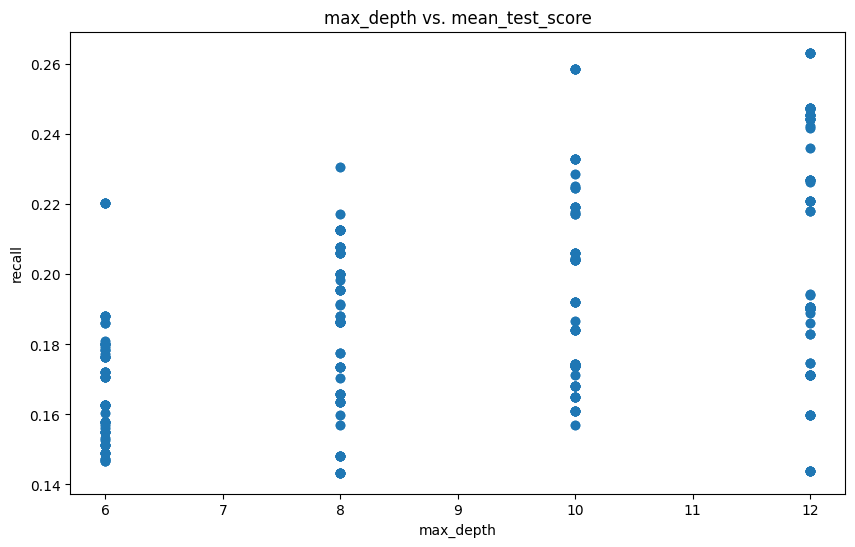

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cv_results_dt['param_max_depth'],
            df_cv_results_dt['mean_test_score'])
plt.title("max_depth vs. mean_test_score")
plt.xlabel("max_depth")
plt.ylabel("recall")
plt.show()

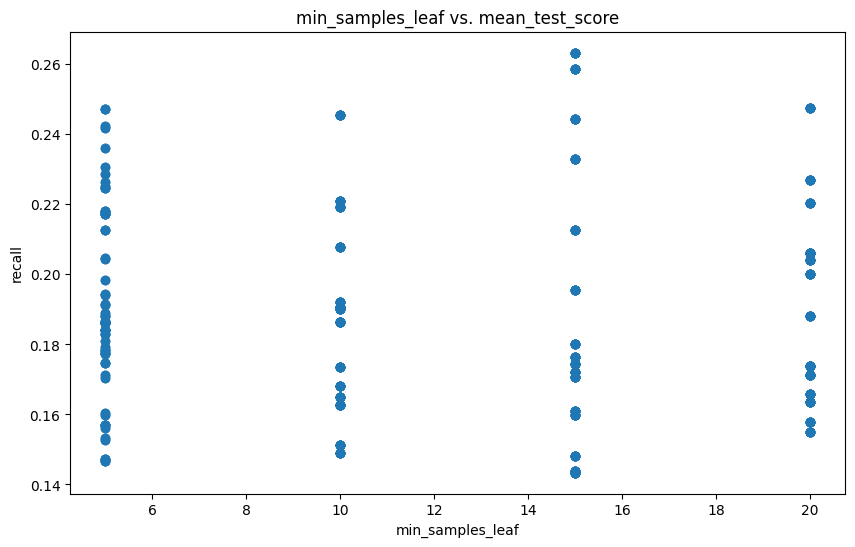

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cv_results_dt['param_min_samples_leaf'],
            df_cv_results_dt['mean_test_score'])
plt.title("min_samples_leaf vs. mean_test_score")
plt.xlabel("min_samples_leaf")
plt.ylabel("recall")
plt.show()

### Busca em grade para o LogisticRegression

In [ ]:
max_iter = np.linspace(100, 300, 5, dtype=int)
c = [0.001, 0.01, 0.1, 1, 10]

param_grid_lr = [
    {'logisticregression__solver' : ['newton-cg', 'lbfgs'],
      'logisticregression__penalty' : ['l2'],
      'logisticregression__max_iter' : max_iter,
       'logisticregression__C' : c},
    {'logisticregression__solver' : ['liblinear'],
      'logisticregression__penalty' : ['l1', 'l2'],
      'logisticregression__max_iter' : max_iter,
      'logisticregression__C' : c},
]

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_grid_search = GridSearchCV(estimator=make_pipeline(StandardScaler(), LogisticRegression(random_state=RANDOM_STATE)),
                               param_grid=param_grid_lr,
                               scoring='recall',
                               n_jobs=-1,
                               cv=cv)

lr_grid_search.fit(x_treino, y_treino)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'logisticregression__C': [0.001, 0.01, 0.1, 1, 10],
                          'logisticregression__max_iter': array([100, 150, 200, 250, 300]),
                          'logisticregression__penalty': ['l2'],
                          'logisticregression__solver': ['newton-cg', 'lbfgs']},
                         {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10],
                          'logisticregression__max_iter': array([100, 150, 200, 250, 300]),
                          'logisticregression__penalty': ['l1', 'l2'],
                          'logisticregression__solver': ['liblinear']}],
             scoring='recall')

In [ ]:
lr_grid_search.best_params_

{'logisticregression__C': 0.001,
 'logisticregression__max_iter': np.int64(100),
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}

In [ ]:
df_cv_results_lr = pd.DataFrame(lr_grid_search.cv_results_)
df_cv_results_lr.head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.026203,0.003439,0.009865,0.002009,0.001,100,l2,newton-cg,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.115506,0.088608,0.079114,0.097468,0.012523,86
1,0.018978,0.002088,0.008105,0.000550,0.001,100,l2,lbfgs,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.113924,0.087025,0.079114,0.096835,0.012313,91
2,0.026165,0.001759,0.007919,0.000276,0.001,150,l2,newton-cg,"{'logisticregression__C': 0.001, 'logisticregr...",0.102848,0.101266,0.115506,0.088608,0.079114,0.097468,0.012523,86


In [ ]:
df_cv_results_lr.loc[[lr_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
51,0.020333,0.001677,0.009687,0.001765,0.001,100,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.251582,0.254747,0.265823,0.248418,0.235759,0.251266,0.009723,1


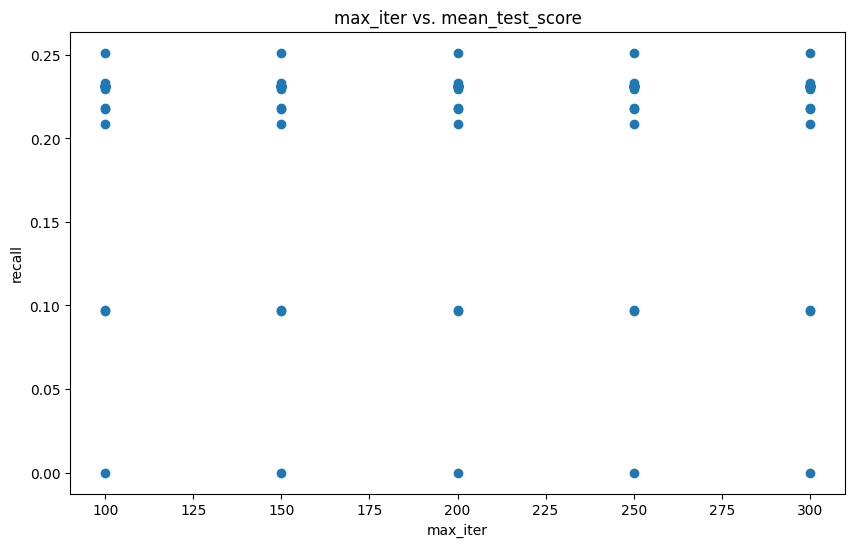

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cv_results_lr['param_logisticregression__max_iter'],
            df_cv_results_lr['mean_test_score'])
plt.title("max_iter vs. mean_test_score")
plt.xlabel("max_iter")
plt.ylabel("recall")
plt.show()

### Busca em grade para o KNN

In [ ]:
param_grid_knn = {
    'knn__n_neighbors': np.linspace(5, 25, 10, dtype=int),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [ ]:
from os import pipe
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_grid_search = GridSearchCV(estimator=pipeline,
                               param_grid=param_grid_knn,
                               scoring='recall',
                               n_jobs=-1,
                               cv=cv)

knn_grid_search.fit(x_treino, y_treino)
knn_grid_search.best_params_

{'knn__metric': 'manhattan',
 'knn__n_neighbors': np.int64(5),
 'knn__weights': 'distance'}

In [ ]:
df_cv_results_knn = pd.DataFrame(knn_grid_search.cv_results_)
df_cv_results_knn.head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__metric,param_knn__n_neighbors,param_knn__weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.028034,0.001112,0.410715,0.020288,euclidean,5,uniform,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.327532,0.324367,0.363924,0.324367,0.294304,0.326899,0.022120,10
1,0.028058,0.001608,0.414438,0.016808,euclidean,5,distance,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.371835,0.362342,0.379747,0.351266,0.318038,0.356646,0.021524,2
2,0.027153,0.000381,0.445192,0.015629,euclidean,7,uniform,"{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.310127,0.306962,0.337025,0.316456,0.319620,0.318038,0.010496,15


In [ ]:
df_cv_results_knn.loc[[knn_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__metric,param_knn__n_neighbors,param_knn__weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
21,0.028121,0.001712,0.662801,0.0123,manhattan,5,distance,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.375,0.370253,0.373418,0.356013,0.357595,0.366456,0.008043,1


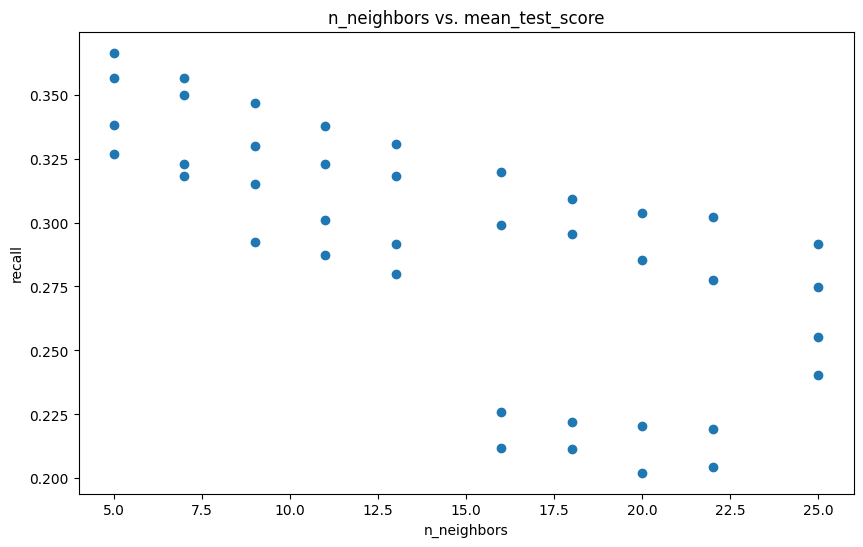

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cv_results_knn['param_knn__n_neighbors'],
            df_cv_results_knn['mean_test_score'])
plt.title("n_neighbors vs. mean_test_score")
plt.xlabel("n_neighbors")
plt.ylabel("recall")
plt.show()

## Validação cruzada aninhada

### Decision Tree

In [ ]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
dt_nested_gs = GridSearchCV(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                            param_grid=param_grid_dt,
                            scoring='recall',
                            n_jobs=-1,
                            cv=inner_cv)

dt_nested_scores = cross_val_score(dt_nested_gs, x_treino, y_treino, cv=outer_cv)

In [ ]:
print(f"Resultado de cada iteração do cv externo: {dt_nested_scores}")
print(f"Média: {dt_nested_scores.mean()}")

Resultado de cada iteração do cv externo: [0.23646724 0.24762808 0.20512821]
Média: 0.2297411750289676


### Logistic Regression

In [ ]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
lr_nested_gs = GridSearchCV(estimator=make_pipeline(StandardScaler(), LogisticRegression(random_state=RANDOM_STATE)),
                            param_grid=param_grid_lr,
                            scoring='recall',
                            n_jobs=-1,
                            cv=inner_cv)

lr_nested_scores = cross_val_score(lr_nested_gs, x_treino, y_treino, cv=outer_cv)

In [ ]:
print("----- Logistic Regression -----")
print(f"Resultado de cada iteração do cv externo: {lr_nested_scores}")
print(f"Média: {lr_nested_scores.mean()}")

----- Logistic Regression -----
Resultado de cada iteração do cv externo: [0.24691358 0.27703985 0.2374169 ]
Média: 0.2537901108426093


In [ ]:
lr_nested_gs.fit(x_treino, y_treino)

print("Melhores hiperparâmetros:")

lr_nested_gs.best_params_

Melhores hiperparâmetros:


{'logisticregression__C': 0.001,
 'logisticregression__max_iter': np.int64(100),
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}

### KNN

In [ ]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_nested_gs = GridSearchCV(estimator=pipeline,
                            param_grid=param_grid_knn,
                            scoring='recall',
                            n_jobs=-1,
                            cv=inner_cv)

knn_nested_scores = cross_val_score(knn_nested_gs, x_treino, y_treino, cv=outer_cv)

In [ ]:
print("----- KNN -----")
print(f"Resultado de cada iteração do cv externo: {knn_nested_scores}")
print(f"Média: {knn_nested_scores.mean()}")

----- KNN -----
Resultado de cada iteração do cv externo: [0.3637227  0.38519924 0.35327635]
Média: 0.3673994304397003


In [ ]:
knn_nested_bs.fit(x_treino, y_treino)

print("Melhores hiperparâmetros:")
knn_nested_bs.best_params_

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before, using random point ['euclidean', np.int64(22), 'distance']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before, using random point ['euclidean', np.int64(8), 'uniform']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before, using random point ['manhattan', np.int64(11), 'distance']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before

Melhores hiperparâmetros:


OrderedDict([('knn__metric', 'manhattan'),
             ('knn__n_neighbors', 6),
             ('knn__weights', 'distance')])

## Busca aleatória

### Decision Tree

In [ ]:
dt_nested_rs = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                                      param_distributions=param_grid_dt,
                                      n_iter=100,
                                      scoring='recall',
                                      n_jobs=-1,
                                      cv=inner_cv,
                                      random_state=RANDOM_STATE)

dt_nested_rs_scores = cross_val_score(dt_nested_rs, x_treino, y_treino, cv=outer_cv)

In [ ]:
print(f"Resultado de cada iteração do cv externo: {dt_nested_rs_scores}")
print(f"Média: {dt_nested_rs_scores.mean()}")

Resultado de cada iteração do cv externo: [0.23646724 0.18975332 0.21272555]
Média: 0.21298203440307595


In [ ]:
dt_nested_rs.fit(x_treino, y_treino)

print("Melhores hiperparâmetros:")
dt_nested_rs.best_params_

Melhores hiperparâmetros:


{'splitter': 'best',
 'min_samples_split': np.int64(5),
 'min_samples_leaf': np.int64(15),
 'max_features': 'sqrt',
 'max_depth': np.int64(12),
 'criterion': 'gini'}

### Logistic Regression

In [ ]:
lr_nested_rs = RandomizedSearchCV(estimator=make_pipeline(StandardScaler(), LogisticRegression(random_state=RANDOM_STATE)),
                                  param_distributions=param_grid_lr,
                                  n_iter=50,
                                  scoring='recall',
                                  n_jobs=-1,
                                  cv=inner_cv,
                                  random_state=RANDOM_STATE)

lr_nested_rs_scores = cross_val_score(lr_nested_rs, x_treino, y_treino, cv=outer_cv)

In [ ]:
print(f"Resultado de cada iteração do cv externo: {lr_nested_rs_scores}")
print(f"Média: {lr_nested_rs_scores.mean()}")

Resultado de cada iteração do cv externo: [0.24691358 0.27703985 0.2374169 ]
Média: 0.2537901108426093


In [ ]:
lr_nested_rs.fit(x_treino, y_treino)

print("Melhores hiperparâmetros:")
lr_nested_rs.best_params_

Melhores hiperparâmetros:


{'logisticregression__solver': 'liblinear',
 'logisticregression__penalty': 'l2',
 'logisticregression__max_iter': np.int64(150),
 'logisticregression__C': 0.001}

### KNN

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_nested_rs = RandomizedSearchCV(estimator=pipeline,
                                  param_distributions=param_grid_knn,
                                  n_iter=50,
                                  scoring='recall',
                                  n_jobs=-1,
                                  cv=inner_cv,
                                  random_state=RANDOM_STATE)

knn_nested_rs_scores = cross_val_score(knn_nested_rs, x_treino, y_treino, cv=outer_cv)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
print(f"Resultado de cada iteração do cv externo: {knn_nested_rs_scores}")
print(f"Média: {knn_nested_rs_scores.mean()}")

Resultado de cada iteração do cv externo: [0.3637227  0.38519924 0.35327635]
Média: 0.3673994304397003


In [ ]:
knn_nested_rs.fit(x_treino, y_treino)

print("Melhores hiperparâmetros:")
knn_nested_rs.best_params_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Melhores hiperparâmetros:


{'knn__weights': 'distance',
 'knn__n_neighbors': np.int64(5),
 'knn__metric': 'manhattan'}

## Otimização Bayesiana

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.3 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

### Decision Tree

In [ ]:
space_dt = {
    'criterion': Categorical(['gini', 'entropy']),
    'max_depth': Integer(6, 12),
    'min_samples_split': Integer(5, 20),
    'min_samples_leaf': Integer(5, 20),
    'max_features': Categorical(['sqrt', 'log2']),
    'splitter': Categorical(['best', 'random'])
}

In [ ]:
dt_nested_bs = BayesSearchCV(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                      search_spaces=space_dt,
                      n_iter=50,
                      scoring='recall',
                      n_jobs=-1,
                      cv=inner_cv,
                      random_state=RANDOM_STATE)

dt_nested_bs_scores = cross_val_score(dt_nested_bs, x_treino, y_treino, cv=outer_cv)

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(11), np.str_('log2'), np.int64(20), np.int64(5), np.str_('best')] before, using random point ['entropy', np.int64(11), 'log2', np.int64(16), np.int64(16), 'best']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('entropy'), np.int64(12), np.str_('log2'), np.int64(20), np.int64(5), np.str_('best')] before, using random point ['gini', np.int64(6), 'log2', np.int64(8), np.int64(15), 'best']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(12), np.str_('log2'), np.int64(20), np.int64(5), np.str_('best')] before, using random point ['entropy', np.int64(11), 'log2', np.int64(16), np.int64(17), 'best']
  warnings.

In [ ]:
print(f"Resultado de cada iteração do cv externo: {dt_nested_bs_scores}")
print(f"Média: {dt_nested_bs_scores.mean()}")

Resultado de cada iteração do cv externo: [0.23931624 0.31973435 0.21272555]
Média: 0.2572587102420541


In [ ]:
dt_nested_bs.fit(x_treino, y_treino)

print("Melhores hiperparâmetros:")
dt_nested_bs.best_params_

Melhores hiperparâmetros:


OrderedDict([('criterion', 'gini'),
             ('max_depth', 12),
             ('max_features', 'log2'),
             ('min_samples_leaf', 15),
             ('min_samples_split', 5),
             ('splitter', 'best')])

### Logistic Regression

In [ ]:
max_iter = Integer(100, 300)
c = Categorical([0.001, 0.01, 0.1, 1, 10])

space_lr = [
    {
        'logisticregression__solver': Categorical(['newton-cg', 'lbfgs']),
        'logisticregression__penalty': Categorical(['l2']),
        'logisticregression__max_iter': max_iter,
        'logisticregression__C': c
    },
    {
        'logisticregression__solver': Categorical(['liblinear']),
        'logisticregression__penalty': Categorical(['l1', 'l2']),
        'logisticregression__max_iter': max_iter,
        'logisticregression__C': c
    },
]

In [ ]:
lr_nested_bs = BayesSearchCV(estimator=make_pipeline(StandardScaler(), LogisticRegression(random_state=RANDOM_STATE)),
                      search_spaces=space_lr,
                      n_iter=50,
                      scoring='recall',
                      n_jobs=-1,
                      cv=inner_cv,
                      random_state=RANDOM_STATE)

lr_nested_bs_scores = cross_val_score(lr_nested_bs, x_treino, y_treino, cv=outer_cv)

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(10), np.int64(134), np.str_('l2'), np.str_('lbfgs')] before, using random point [0.001, np.int64(217), 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(10), np.int64(134), np.str_('l2'), np.str_('lbfgs')] before, using random point [0.001, np.int64(217), 'l2', 'lbfgs']
  warnings.warn(


In [ ]:
print(f"Resultado de cada iteração do cv externo: {lr_nested_bs_scores}")
print(f"Média: {lr_nested_bs_scores.mean()}")

Resultado de cada iteração do cv externo: [0.24691358 0.27703985 0.2374169 ]
Média: 0.2537901108426093


In [ ]:
lr_nested_bs.fit(x_treino, y_treino)

print("Melhores hiperparâmetros:")
lr_nested_bs.best_params_

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(10), np.int64(134), np.str_('l2'), np.str_('lbfgs')] before, using random point [0.001, np.int64(217), 'l2', 'lbfgs']
  warnings.warn(


Melhores hiperparâmetros:


OrderedDict([('logisticregression__C', 0.001),
             ('logisticregression__max_iter', 150),
             ('logisticregression__penalty', 'l2'),
             ('logisticregression__solver', 'liblinear')])

In [ ]:
lr_nested_bs.predict(x_teste)

array([0, 1, 0, ..., 0, 0, 0])

### KNN

In [ ]:
space_knn = {
    'knn__n_neighbors': Integer(5, 25),
    'knn__weights': Categorical(['uniform', 'distance']),
    'knn__metric': Categorical(['euclidean', 'manhattan'])
}

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_nested_bs = BayesSearchCV(estimator=pipeline,
                              search_spaces=space_knn,
                              n_iter=50,
                              scoring='recall',
                              n_jobs=-1,
                              cv=inner_cv,
                              random_state=RANDOM_STATE)

knn_nested_bs_scores = cross_val_score(knn_nested_bs, x_treino, y_treino, cv=outer_cv)

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before, using random point ['euclidean', np.int64(7), 'distance']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before, using random point ['manhattan', np.int64(16), 'distance']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before, using random point ['euclidean', np.int64(25), 'uniform']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before

In [ ]:
print(f"Resultado de cada iteração do cv externo: {knn_nested_bs_scores}")
print(f"Média: {knn_nested_bs_scores.mean()}")

Resultado de cada iteração do cv externo: [0.3637227  0.38519924 0.35327635]
Média: 0.3673994304397003


In [ ]:
knn_nested_bs.fit(x_treino, y_treino)

print("Melhores hiperparâmetros:")
knn_nested_bs.best_params_

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before, using random point ['euclidean', np.int64(22), 'distance']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before, using random point ['euclidean', np.int64(8), 'uniform']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before, using random point ['manhattan', np.int64(11), 'distance']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(5), np.str_('distance')] before

Melhores hiperparâmetros:


OrderedDict([('knn__metric', 'manhattan'),
             ('knn__n_neighbors', 6),
             ('knn__weights', 'distance')])